In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import joblib

model = joblib.load('linear_regression_v1.pkl')
df = pd.read_csv("cleaned_data.csv")
df

,姓名,age,成績,city,status
0,Eric,24.0,430.0,1,Pass
1,gpt,10.0,167.5,2,Pass
2,A,45.0,56.0,0,Fail
3,B,66.0,16.6,4,Fail
4,Anonymous,67.0,167.5,5,Pass


In [2]:
new_row = pd.DataFrame({
    "姓名": ["SuperOld"], 
    "age": [90.0], 
    "成績": [500.0], 
    "city": [1], 
    "status": ["Pass"]
})

df_chaos = pd.concat([df, new_row], ignore_index=True)
print("搗蛋數據已加入！現在總共有 6 筆資料。")
df_chaos

搗蛋數據已加入！現在總共有 6 筆資料。


,姓名,age,成績,city,status
0,Eric,24.0,430.0,1,Pass
1,gpt,10.0,167.5,2,Pass
2,A,45.0,56.0,0,Fail
3,B,66.0,16.6,4,Fail
4,Anonymous,67.0,167.5,5,Pass
5,SuperOld,90.0,500.0,1,Pass


In [3]:
X_new = df_chaos[["age"]]
y_new = df_chaos["成績"]

model_v2 = LinearRegression()
model_v2.fit(X_new , y_new)

print(f"新模型 - 年齡每增加一歲，分數改變：{model_v2.coef_[0]:.2f} 分")

新模型 - 年齡每增加一歲，分數改變：1.01 分


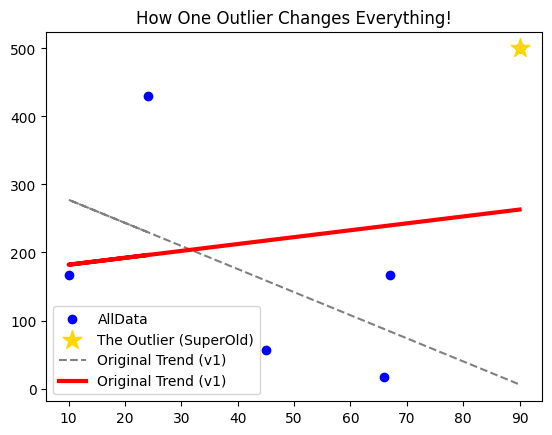

In [4]:
plt.Figure(figsize=(10 , 6))

plt.scatter(df_chaos["age"], df_chaos["成績"], color = 'blue', label = 'AllData')
plt.scatter(90, 500, color='gold', s=200, marker='*', label='The Outlier (SuperOld)')

plt.plot(df_chaos["age"] , model.predict(df_chaos[["age"]]) , color = 'gray' , linestyle = '--' , label='Original Trend (v1)')
plt.plot(df_chaos["age"] , model_v2.predict(df_chaos[["age"]]) , color = 'red' , linewidth = 3 , label='Original Trend (v1)')

plt.title("How One Outlier Changes Everything!")
plt.legend()
plt.show()

In [5]:
joblib.dump(model, 'linear_regression_v2.pkl')
print("模型 v2 已儲存成功！")

模型 v2 已儲存成功！


In [6]:
df_chaos.to_csv("data_chaos.csv", index=False)